##### Time Series Analysis (Temporal Trends)

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy import stats

In [29]:
path= r"/Users/obanoyenracheal/Python/Practise/Temperature_Monthly_Data_1994_2024.csv"


In [30]:
df = pd.read_csv(path)
df.head(10)

,PARAMETER,YEAR,LAT,LON,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC,ANN
0,T2M,1994,19.5,87.500,24.18,24.52,26.47,28.02,29.03,28.80,27.97,27.64,28.03,27.73,26.81,24.29,26.97
1,T2M,1994,19.5,88.125,24.21,24.44,26.43,27.99,29.00,28.78,28.04,27.60,27.87,27.78,26.82,24.44,26.96
2,T2M,1994,19.5,88.750,24.25,24.44,26.33,27.97,28.92,28.72,28.00,27.61,27.79,27.80,26.86,24.61,26.95
3,T2M,1994,19.5,89.375,24.18,24.43,26.20,27.94,28.84,28.71,27.95,27.62,27.79,27.79,26.91,24.65,26.93
4,T2M,1994,19.5,90.000,24.07,24.39,26.05,27.92,28.86,28.75,27.95,27.51,27.82,27.77,26.96,24.56,26.89
5,T2M,1994,19.5,90.625,23.96,24.39,25.86,27.92,28.90,28.80,27.96,27.40,27.81,27.76,27.00,24.52,26.87
6,T2M,1994,19.5,91.250,23.78,24.34,25.62,27.90,28.92,28.72,27.99,27.34,27.73,27.77,27.04,24.51,26.81
7,T2M,1994,19.5,91.875,23.78,24.21,25.47,27.85,28.83,28.54,28.01,27.34,27.72,27.86,27.10,24.66,26.79
8,T2M,1994,19.5,92.500,24.07,24.34,25.41,27.83,28.79,28.43,28.06,27.41,27.68,27.88,27.18,24.82,26.83
9,T2M,1994,20.0,87.500,24.09,24.32,26.46,28.09,29.03,28.72,28.15,27.82,28.20,27.79,26.79,24.12,26.98


In [31]:
# Display data shape
print(f"\nData shape: {df.shape}")

#Check the column names
print(f"\nColumn names: {df.columns.tolist()}")


Data shape: (4185, 17)

Column names: ['PARAMETER', 'YEAR', 'LAT', 'LON', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANN']


#### DATA OVERVIEW

In [32]:
#Data overview
print("TEMPERATURE TIME SERIES ANALYSIS (1994-2024)")

print("DATA OVERVIEW")
total_records = len(df)
print(f"Total records: {total_records}")

min_year = df['YEAR'].min()
max_year = df['YEAR'].max()
print(f"Years covered: {min_year} to {max_year}")

num_locations = df[['LAT', 'LON']].drop_duplicates().shape[0]
print(f"Unique locations: {num_locations}")

TEMPERATURE TIME SERIES ANALYSIS (1994-2024)
DATA OVERVIEW
Total records: 4185
Years covered: 1994 to 2024
Unique locations: 135


In [33]:
# Calculate annual average temperature (average across all locations per year)
annual_temps = df.groupby('YEAR')['ANN'].mean()
print("ANNUAL TEMPERATURE STATISTICS")

mean_temp = annual_temps.mean()
print(f"   Mean annual temperature (1994-2024): {mean_temp:.2f}°C")

min_temp = annual_temps.min()
min_year_val = annual_temps.idxmin()
print(f"   Minimum annual temperature: {min_temp:.2f}°C (Year: {min_year_val})")

max_temp = annual_temps.max()
max_year_val = annual_temps.idxmax()
print(f"   Maximum annual temperature: {max_temp:.2f}°C (Year: {max_year_val})")

std_temp = annual_temps.std()
print(f"   Standard deviation: {std_temp:.2f}°C")

ANNUAL TEMPERATURE STATISTICS
   Mean annual temperature (1994-2024): 25.66°C
   Minimum annual temperature: 25.18°C (Year: 2000)
   Maximum annual temperature: 26.15°C (Year: 1994)
   Standard deviation: 0.27°C


### LINEAR REGRESSION TREND ANALYSIS

In [34]:
# Extract years and temperatures as arrays
years = np.array(annual_temps.index)
temps = annual_temps.values

# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(years, temps)

# Calculate trend per decade (10 years)
trend_per_decade = slope * 10

print("TREND ANALYSIS (Linear Regression)")
print(f"Slope: {slope:.6f}°C/year")
print(f"Temperature change per decade: {trend_per_decade:.3f}°C")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.4e}")

# Check statistical significance
if p_value < 0.05:
    print(f"Trend is STATISTICALLY SIGNIFICANT (p < 0.05)")
else:
    print(f"Trend is NOT statistically significant (p ≥ 0.05)")

TREND ANALYSIS (Linear Regression)
Slope: -0.000185°C/year
Temperature change per decade: -0.002°C
R-squared: 0.0000
P-value: 9.7320e-01
Trend is NOT statistically significant (p ≥ 0.05)


In [35]:
# Create decade column
df['Decade'] = (df['YEAR'] // 10) * 10

# Calculate average temperature by decade
decadal_temps = df.groupby('Decade')['ANN'].mean()

print("TEMPERATURE BY DECADE")
for decade, temp in decadal_temps.items():
    print(f"   {int(decade)}s: {temp:.2f}°C")

TEMPERATURE BY DECADE
   1990s: 25.84°C
   2000s: 25.51°C
   2010s: 25.69°C
   2020s: 25.69°C


In [36]:
# Calculate average temperature for each month and identify seasonal patterns

# List of months
months = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

# Calculate average temperature for each month
monthly_avg = []
for month in months:
    avg = df[month].mean()
    monthly_avg.append(avg)

# Find warmest and coldest months
warmest_idx = np.argmax(monthly_avg)
coldest_idx = np.argmin(monthly_avg)
warmest_month = months[warmest_idx]
coldest_month = months[coldest_idx]
max_monthly = max(monthly_avg)
min_monthly = min(monthly_avg)
seasonal_range = max_monthly - min_monthly

print("SEASONAL PATTERN (Average Monthly Temperatures)")
print(f"Warmest month: {warmest_month} ({max_monthly:.2f}°C)")
print(f"Coldest month: {coldest_month} ({min_monthly:.2f}°C)")
print(f"Seasonal range: {seasonal_range:.2f}°C")

SEASONAL PATTERN (Average Monthly Temperatures)
Warmest month: MAY (29.48°C)
Coldest month: JAN (18.87°C)
Seasonal range: 10.61°C


In [37]:
# Calculate year-on-year change
yoy_change = annual_temps.diff()

# Count warming and cooling years
warming_years = (yoy_change > 0).sum()
cooling_years = (yoy_change < 0).sum()
total_years = len(yoy_change) - 1

# Calculate percentages
warming_pct = (warming_years / total_years) * 100
cooling_pct = (cooling_years / total_years) * 100

print("\n6. YEAR-ON-YEAR TEMPERATURE CHANGE")
print(f"   Warming years: {warming_years} ({warming_pct:.1f}%)")
print(f"   Cooling years: {cooling_years} ({cooling_pct:.1f}%)")

# Average increases and decreases
avg_increase = yoy_change[yoy_change > 0].mean()
avg_decrease = yoy_change[yoy_change < 0].mean()

print(f"   Avg increase (warming years): {avg_increase:.3f}°C")
print(f"   Avg decrease (cooling years): {avg_decrease:.3f}°C")


6. YEAR-ON-YEAR TEMPERATURE CHANGE
   Warming years: 18 (60.0%)
   Cooling years: 12 (40.0%)
   Avg increase (warming years): 0.200°C
   Avg decrease (cooling years): -0.326°C


In [38]:
from statsmodels.tsa.arima.model import ARIMA
import statsmodels
print(statsmodels.__version__)
from statsmodels.tsa.arima.model import ARIMA
print("ARIMA is ready to use!")

0.14.6
ARIMA is ready to use!


### FORECAST ANALYSIS (5 YEARS)


FORECAST ANALYSIS (ARIMA Model, Next 5 Years)
Year 2025: 25.73°C
Year 2026: 25.69°C
Year 2027: 25.68°C
Year 2028: 25.67°C
Year 2029: 25.67°C

Forecast Confidence Intervals (95%):
Year 2025: 25.22°C - 26.24°C
Year 2026: 25.15°C - 26.23°C
Year 2027: 25.13°C - 26.23°C
Year 2028: 25.12°C - 26.22°C
Year 2029: 25.12°C - 26.22°C


/opt/miniconda3/envs/python-gis/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/python-gis/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/python-gis/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/python-gis/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py

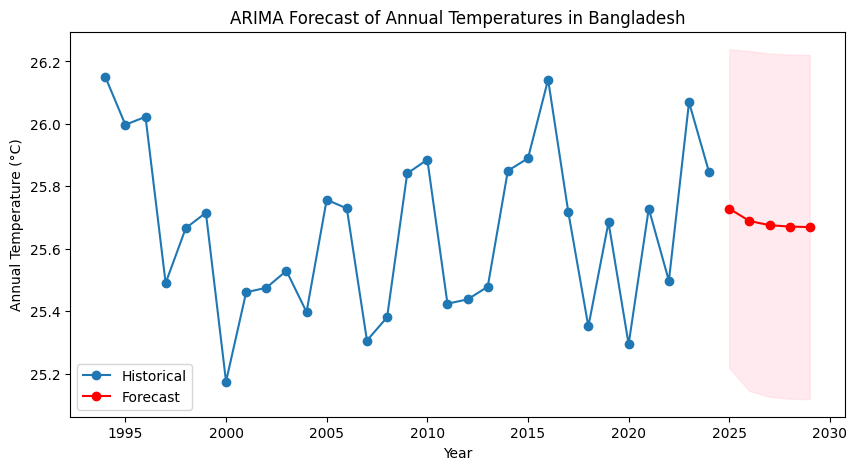

In [39]:
# --- ARIMA Forecasting for Next 5 Years ---
from statsmodels.tsa.arima.model import ARIMA

# Your annual temperature series is already calculated
# annual_temps: index = YEAR, values = mean temperature

# ARIMA model
model = ARIMA(annual_temps, order=(1,1,1))
model_fit = model.fit()

# Forecast the next 5 years
forecast_steps = 5
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_values = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Index for forecasted years
last_year = annual_temps.index[-1]
forecast_years = np.arange(last_year + 1, last_year + forecast_steps + 1)

# Display forecast results
print("\nFORECAST ANALYSIS (ARIMA Model, Next 5 Years)")
for year, temp in zip(forecast_years, forecast_values):
    print(f"Year {year}: {temp:.2f}°C")

print("\nForecast Confidence Intervals (95%):")
for year, (lower, upper) in zip(forecast_years, forecast_conf_int.values):
    print(f"Year {year}: {lower:.2f}°C - {upper:.2f}°C")

# Plot historical and forecasted temperatures
plt.figure(figsize=(10,5))
plt.plot(annual_temps.index, annual_temps.values, label='Historical', marker='o')
plt.plot(forecast_years, forecast_values, label='Forecast', marker='o', color='red')
plt.fill_between(forecast_years,
                 forecast_conf_int.iloc[:,0],
                 forecast_conf_int.iloc[:,1],
                 color='pink', alpha=0.3)
plt.xlabel('Year')
plt.ylabel('Annual Temperature (°C)')
plt.title('ARIMA Forecast of Annual Temperatures in Bangladesh')
plt.legend()
plt.show()

### VISUALISATION

/var/folders/pg/n3ynbd3j68xbl45h32m850700000gn/T/ipykernel_3181/1054188720.py:41: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(decade_data, labels=decade_labels, patch_artist=True)



✓ Visualization saved: temperature_timeseries_analysis.png


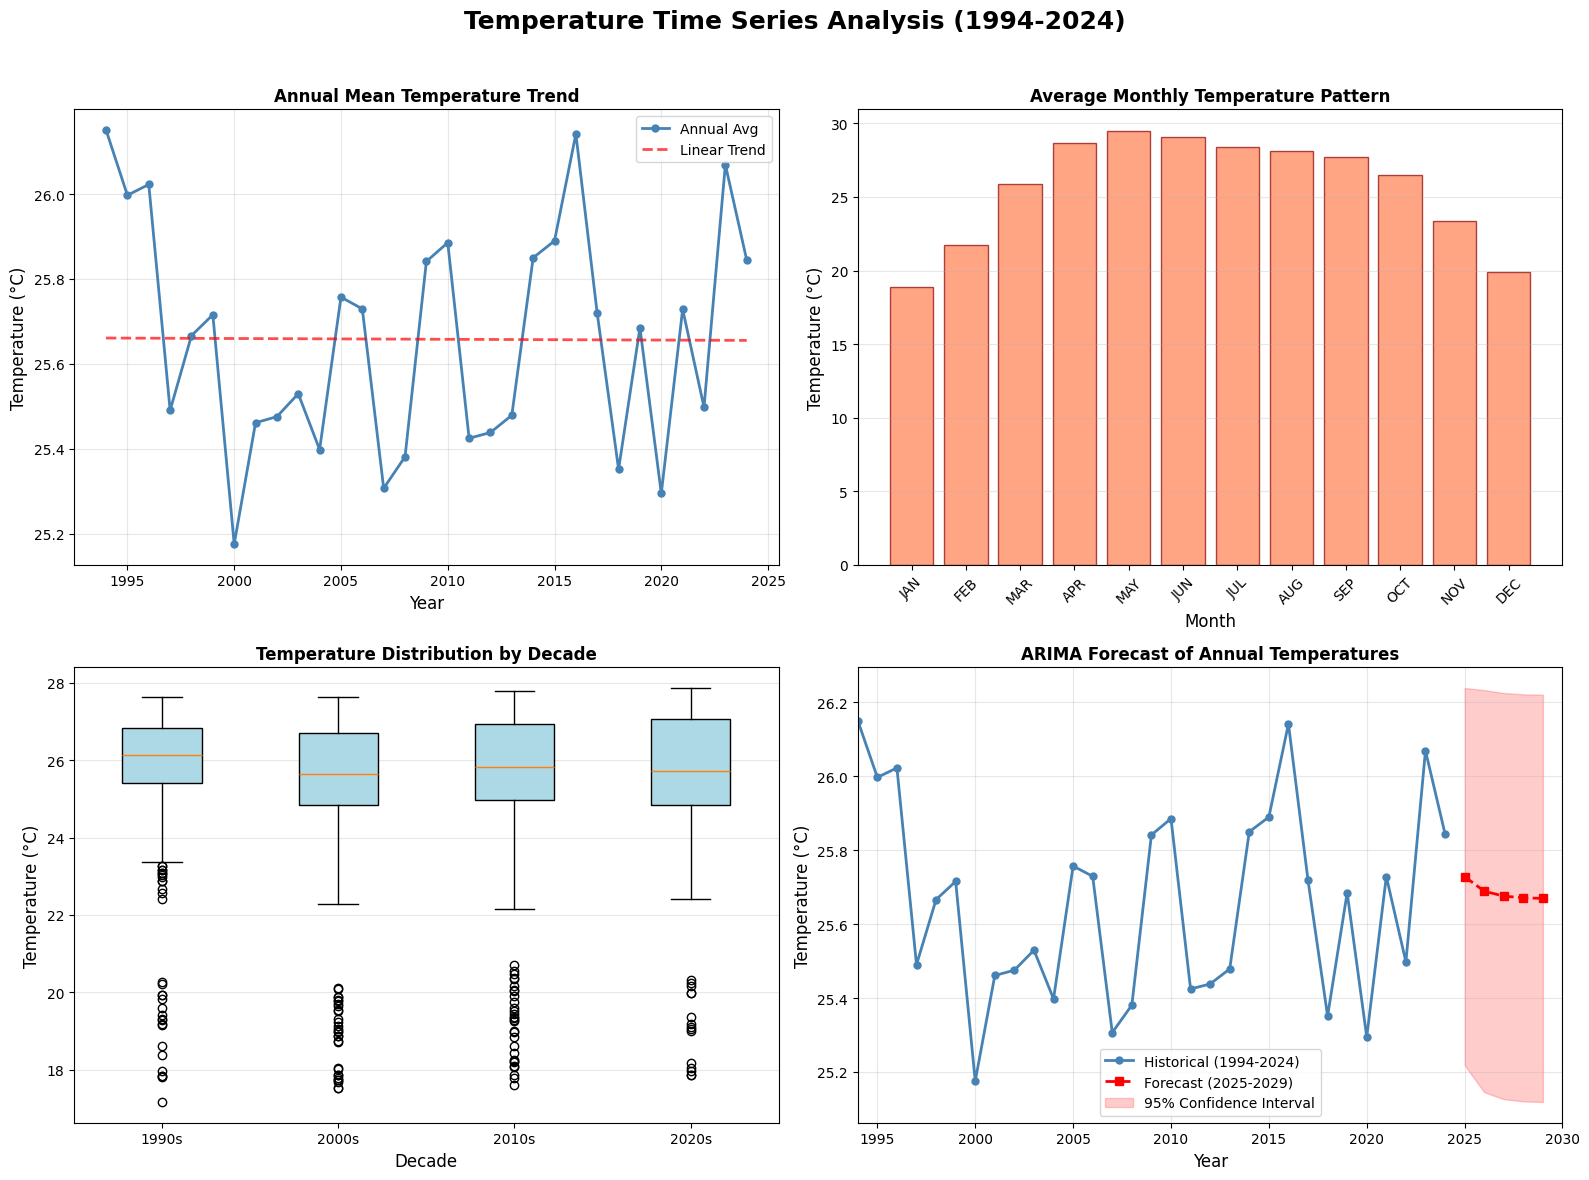

In [40]:
# --- Visualization: 4 Subplots ---
import matplotlib.pyplot as plt

# Create a figure with 4 subplots (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temperature Time Series Analysis (1994-2024)', 
             fontsize=18, fontweight='bold')

# ===== PLOT 1: Annual Temperature Trend =====
ax1 = axes[0, 0]
ax1.plot(years, temps, 'o-', color='steelblue', linewidth=2, markersize=5, label='Annual Avg')

# Linear regression line
z = np.polyfit(years, temps, 1)
p = np.poly1d(z)
ax1.plot(years, p(years), '--', color='red', linewidth=2, alpha=0.7, label='Linear Trend')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Annual Mean Temperature Trend', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# ===== PLOT 2: Monthly Seasonal Pattern =====
ax2 = axes[0, 1]
month_nums = np.arange(1, 13)
ax2.bar(month_nums, monthly_avg, color='coral', alpha=0.7, edgecolor='darkred')
ax2.set_xticks(month_nums)
ax2.set_xticklabels(months, rotation=45)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Temperature (°C)', fontsize=12)
ax2.set_title('Average Monthly Temperature Pattern', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# ===== PLOT 3: Temperature Distribution by Decade =====
ax3 = axes[1, 0]
decades = sorted(df['Decade'].unique())
decade_data = [df[df['Decade'] == decade]['ANN'].values for decade in decades]
decade_labels = [f"{int(d)}s" for d in decades]

bp = ax3.boxplot(decade_data, labels=decade_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')

ax3.set_xlabel('Decade', fontsize=12)
ax3.set_ylabel('Temperature (°C)', fontsize=12)
ax3.set_title('Temperature Distribution by Decade', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# ===== PLOT 4: Forecast (ARIMA) =====
ax4 = axes[1, 1]

# Historical data
ax4.plot(years, temps, 'o-', color='steelblue', linewidth=2, markersize=5, label='Historical (1994-2024)')

# Forecasted temperatures
ax4.plot(forecast_years, forecast_values, 's--', color='red', linewidth=2, markersize=6, label='Forecast (2025-2029)')

# Confidence interval (from ARIMA forecast)
lower_bound = forecast_conf_int.iloc[:, 0]
upper_bound = forecast_conf_int.iloc[:, 1]
ax4.fill_between(forecast_years, lower_bound, upper_bound, color='red', alpha=0.2, label='95% Confidence Interval')

ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel('Temperature (°C)', fontsize=12)
ax4.set_title('ARIMA Forecast of Annual Temperatures', fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.legend()
ax4.set_xlim(1994, forecast_years[-1] + 1)

# Adjust layout and save figure
plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave space for suptitle
plt.savefig('temperature_timeseries_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: temperature_timeseries_analysis.png")

plt.show()
plt.show()

In [41]:
# ==========================
# PRINT FORMATTED CONCLUSIONS
# ==========================
print("\nCONCLUSIONS")
print("="*70)

# 1. Trend Analysis Result
print("\n1. TREND ANALYSIS RESULT:")
if p_value < 0.05:
    print(f"   There IS a significant temperature trend: {trend_per_decade:.3f}°C per decade")
else:
    print(f"   There is NO significant temperature trend")
    print(f"   The trend is {trend_per_decade:.3f}°C per decade (not statistically significant)")

# 2. Temperature Stability
range_temp = max_temp - min_temp
print("\n2. TEMPERATURE STABILITY:")
print(f"   Temperature range over 30 years: {range_temp:.2f}°C")
print(f"   This indicates a stable/consistent climate")

# 3. Seasonal Pattern
print("\n3. SEASONAL PATTERN:")
print(f"   Clear seasonal variation of {seasonal_range:.2f}°C")
print(f"   Warmest month: {warmest_month} ({max_monthly:.2f}°C)")
print(f"   Coldest month: {coldest_month} ({min_monthly:.2f}°C)")
print(f"   Typical of tropical/monsoon climate regions")

# 4. Year-to-Year Variability
print("\n4. YEAR-TO-YEAR VARIABILITY:")
print(f"   {warming_pct:.0f}% of years show warming")
print(f"   {cooling_pct:.0f}% of years show cooling")
print(f"   Average increase (warming years): {avg_increase:.3f}°C")
print(f"   Average decrease (cooling years): {avg_decrease:.3f}°C")
print(f"   This reflects natural variability without a systematic trend")

# 5. Forecast (2025-2029) using ARIMA
print("\n5. FORECAST FOR 2025-2029 (ARIMA Model):")
forecast_mean = forecast_values.mean()
forecast_min = forecast_values.min()
forecast_max = forecast_values.max()
forecast_uncertainty = ((forecast_conf_int.iloc[:,1] - forecast_conf_int.iloc[:,0]) / 2).mean()

print(f"   Average forecasted temperature: {forecast_mean:.2f}°C")
print(f"   Forecasted range: {forecast_min:.2f}°C to {forecast_max:.2f}°C")
print(f"   Approximate uncertainty: ±{forecast_uncertainty:.2f}°C (95% confidence)")
print(f"   Note: Forecast assumes current climate trends continue based on ARIMA modeling")


CONCLUSIONS

1. TREND ANALYSIS RESULT:
   There is NO significant temperature trend
   The trend is -0.002°C per decade (not statistically significant)

2. TEMPERATURE STABILITY:
   Temperature range over 30 years: 0.98°C
   This indicates a stable/consistent climate

3. SEASONAL PATTERN:
   Clear seasonal variation of 10.61°C
   Warmest month: MAY (29.48°C)
   Coldest month: JAN (18.87°C)
   Typical of tropical/monsoon climate regions

4. YEAR-TO-YEAR VARIABILITY:
   60% of years show warming
   40% of years show cooling
   Average increase (warming years): 0.200°C
   Average decrease (cooling years): -0.326°C
   This reflects natural variability without a systematic trend

5. FORECAST FOR 2025-2029 (ARIMA Model):
   Average forecasted temperature: 25.69°C
   Forecasted range: 25.67°C to 25.73°C
   Approximate uncertainty: ±0.54°C (95% confidence)
   Note: Forecast assumes current climate trends continue based on ARIMA modeling
